In [10]:
import heapq
import math
import random
from collections import deque
from dataclasses import dataclass, field
from statistics import fmean, stdev
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


In [11]:
CONFIGURACIONES = [
    # (nombre, num_muelles, num_remolcadores, descripcion)
    ("base_3_1", 3, 1, "Configuración original"),
    ("mas_remolcadores_3_2", 3, 2, "2 remolcadores, 3 muelles"),
    ("iguales_3_3", 3, 3, "3 remolcadores, 3 muelles"), 
    ("mas_muelles_4_1", 4, 1, "1 remolcador, 4 muelles"),
    ("mejorado_4_2", 4, 2, "2 remolcadores, 4 muelles"),
    ("extremo_5_1", 5, 1, "1 remolcador, 5 muelles"),  
     ("extremo_100_1", 100, 1, "1 remolcador, 100 muelles"),  
     ("extremo_100_50", 100, 50, "50 remolcadores, 100 muelles"), 
    ("extremo_100_70", 100, 70, "70 remolcadores, 100 muelles"), 
]

NUM_SHIPS = 100_000
REPLICATIONS = 50
SEED = 42

MEAN_INTERARRIVAL_TIME = 8.0
MEAN_INBOUND_TOW_TIME = 2.0
MEAN_OUTBOUND_TOW_TIME = 1.0
MEAN_EMPTY_TRAVEL_TIME = 0.25  # 15 minutes 

PORT = "port"
DOCKS = "docks"

TANKER_TYPES = [
    ("small", 0.25, 9.0, 1.0),
    ("medium", 0.25, 12.0, 2.0),
    ("large", 0.50, 18.0, 3.0),
]

In [12]:


@dataclass
class Ship:
    id: int
    tanker_type: str
    arrival_time: float
    loading_duration: float
    inbound_tow_start: float | None = None
    loading_start: float | None = None
    loading_end: float | None = None
    outbound_tow_start: float | None = None
    departure_time: float | None = None

@dataclass(order=True)
class Event:
    time: float
    order: int
    name: str = field(compare=False)
    ship_id: int | None = field(default=None, compare=False)


In [13]:

class PortSimulation:
    def __init__(self, seed, num_docks, num_tugs):
        self.rng = random.Random(seed)

        self.num_docks = num_docks          
        self.num_tugs = num_tugs  
        
        self.current_time = 0.0
        self.event_order = 0
        self.event_queue = []

        self.ships = {}
        self.ships_created = 0
        self.ships_finished = 0

        self.inbound_queue = deque()
        self.outbound_queue = deque()

        self.available_docks = num_docks     
        self.available_tugs = num_tugs 

        self.available_tugs = 1
        self.tug_location = PORT

        self.inbound_waits = []
        self.time_until_loading_values = []
        self.outbound_waits = []
        self.total_times = []

    def simulate(self):
        self.schedule(self.exponential(MEAN_INTERARRIVAL_TIME), "arrival")

        while self.ships_finished < NUM_SHIPS:
            event = heapq.heappop(self.event_queue)
            self.current_time = event.time
            self.process_event(event)
            self.dispatch_tug()

        return {
            "inbound_wait": fmean(self.inbound_waits),
            "time_until_loading": fmean(self.time_until_loading_values),
            "outbound_wait": fmean(self.outbound_waits),
            "total_time": fmean(self.total_times),
        }

    def schedule(self, time, name, ship_id=None):
        self.event_order += 1
        event = Event(time, self.event_order, name, ship_id)
        heapq.heappush(self.event_queue, event)

    def process_event(self, event):
        if event.name == "arrival":
            self.handle_arrival()
        elif event.name == "inbound_tow_complete":
            self.handle_inbound_tow_complete(event.ship_id)
        elif event.name == "loading_complete":
            self.handle_loading_complete(event.ship_id)
        elif event.name == "outbound_tow_complete":
            self.handle_outbound_tow_complete(event.ship_id)
        elif event.name == "empty_arrive_port":
            self.handle_empty_arrive_port()
        elif event.name == "empty_arrive_docks":
            self.handle_empty_arrive_docks()
  

    def handle_arrival(self):
        self.ships_created += 1
        tanker_type, mean_loading, loading_variance = self.choose_tanker_type()

        ship = Ship(
            id=self.ships_created,
            tanker_type=tanker_type,
            arrival_time=self.current_time,
            loading_duration=self.positive_normal(mean_loading, loading_variance),
        )
        self.ships[ship.id] = ship
        self.inbound_queue.append(ship.id)

        if self.ships_created < NUM_SHIPS:
            next_time = self.current_time + self.exponential(MEAN_INTERARRIVAL_TIME)
            self.schedule(next_time, "arrival")

    def handle_inbound_tow_complete(self, ship_id):
        ship = self.ships[ship_id]
        ship.loading_start = self.current_time

        self.tug_location = DOCKS
        self.available_tugs += 1

        self.schedule(self.current_time + ship.loading_duration, "loading_complete", ship.id)

    def handle_loading_complete(self, ship_id):
        ship = self.ships[ship_id]
        ship.loading_end = self.current_time
        self.outbound_queue.append(ship.id)

    def handle_outbound_tow_complete(self, ship_id):
        ship = self.ships[ship_id]
        ship.departure_time = self.current_time

        self.available_docks += 1
        self.tug_location = PORT
        self.available_tugs += 1
        self.ships_finished += 1

        self.save_metrics(ship)

    def handle_empty_arrive_port(self):
        self.tug_location = PORT
        self.available_tugs += 1

    def handle_empty_arrive_docks(self):
        self.tug_location = DOCKS
        self.available_tugs += 1

    def dispatch_tug(self):
        if self.available_tugs == 0:
            return

        if self.tug_location == PORT:
            if self.inbound_queue and self.available_docks > 0:
                self.start_inbound_tow()
            elif self.outbound_queue:
                self.travel_empty(DOCKS)

        elif self.tug_location == DOCKS:
            if self.outbound_queue:
                self.start_outbound_tow()
            elif self.inbound_queue and self.available_docks > 0:
                self.travel_empty(PORT)

    def start_inbound_tow(self):
        ship_id = self.inbound_queue.popleft()
        ship = self.ships[ship_id]
        ship.inbound_tow_start = self.current_time

        self.available_docks -= 1
        self.available_tugs -= 1

        finish_time = self.current_time + self.exponential(MEAN_INBOUND_TOW_TIME)
        self.schedule(finish_time, "inbound_tow_complete", ship.id)

    def start_outbound_tow(self):
        ship_id = self.outbound_queue.popleft()
        ship = self.ships[ship_id]
        ship.outbound_tow_start = self.current_time

        self.available_tugs -= 1

        finish_time = self.current_time + self.exponential(MEAN_OUTBOUND_TOW_TIME)
        self.schedule(finish_time, "outbound_tow_complete", ship.id)

    def travel_empty(self, destination):
        self.available_tugs -= 1
        finish_time = self.current_time + self.exponential(MEAN_EMPTY_TRAVEL_TIME)

        if destination == PORT:
            self.schedule(finish_time, "empty_arrive_port")
        else:
            self.schedule(finish_time, "empty_arrive_docks")

    def save_metrics(self, ship):
        self.inbound_waits.append(ship.inbound_tow_start - ship.arrival_time)
        self.time_until_loading_values.append(ship.loading_start - ship.arrival_time)
        self.outbound_waits.append(ship.outbound_tow_start - ship.loading_end)
        self.total_times.append(ship.departure_time - ship.arrival_time)

    def choose_tanker_type(self):
        selected_tanker = self.rng.choices(
            TANKER_TYPES,
            weights=[probability for _, probability, _, _ in TANKER_TYPES],
            k=1,
        )[0]

        name, _, mean, variance = selected_tanker
        return name, mean, variance

    def exponential(self, mean):
        return self.rng.expovariate(mean)

    def positive_normal(self, mean, variance):
        standard_deviation = math.sqrt(variance)
        value = self.rng.normalvariate(mean, standard_deviation)

        while value <= 0.0:
            value = self.rng.normalvariate(mean, standard_deviation)

        return value



In [14]:

def plot_simulation_results(results):

    plt.style.use('seaborn-v0_8-darkgrid')
    fig1, ax1 = plt.subplots(figsize=(12, 6))
    
    labels = [
        "Espera antes de\nremolque entrada",
        "Tiempo hasta\ncomenzar carga",
        "Espera en muelle\npara salir",
        "Tiempo total\nen sistema"
    ]
    
    metrics_keys = ["inbound_wait", "time_until_loading", "outbound_wait", "total_time"]
    means = []
    errors = []
    
    for key in metrics_keys:
        values = [r[key] for r in results]
        mean = fmean(values)
        if len(values) > 1:
            error = 1.96 * stdev(values) / math.sqrt(len(values))
        else:
            error = 0
        means.append(mean)
        errors.append(error)
    
    x_pos = np.arange(len(labels))
    bars = ax1.bar(x_pos, means, yerr=errors, capsize=5, alpha=0.7, 
                   color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
    ax1.set_ylabel('Tiempo (horas)', fontsize=12)
    ax1.set_title(f'Resultados de Simulación - {len(results)} Réplicas', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(labels, fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')
    

    for bar, mean, error in zip(bars, means, errors):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + error + 0.5,
                f'{mean:.2f}±{error:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    
    data_to_plot = []
    for key in metrics_keys:
        values = [r[key] for r in results]
        data_to_plot.append(values)
    
    bp = ax2.boxplot(data_to_plot, labels=labels, patch_artist=True)
    
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Tiempo (horas)', fontsize=12)
    ax2.set_title(f'Distribución de Métricas entre {len(results)} Réplicas', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()
    

    fig3, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (key, label) in enumerate(zip(metrics_keys, labels)):
        ax = axes[idx]
        values = [r[key] for r in results]
        
        cumulative_means = [fmean(values[:i+1]) for i in range(len(values))]
        

        ci_upper = []
        ci_lower = []
        for i in range(1, len(values)+1):
            mean_i = fmean(values[:i])
            if i > 1:
                se = stdev(values[:i]) / math.sqrt(i)
                ci_upper.append(mean_i + 1.96 * se)
                ci_lower.append(mean_i - 1.96 * se)
            else:
                ci_upper.append(mean_i)
                ci_lower.append(mean_i)
        
        replicas = range(1, len(values)+1)
        ax.plot(replicas, cumulative_means, 'b-', linewidth=2, label='Media acumulada')
        ax.fill_between(replicas, ci_lower, ci_upper, alpha=0.3, color='blue', label='IC 95%')
        ax.axhline(y=cumulative_means[-1], color='r', linestyle='--', 
                  alpha=0.7, label=f'Media final: {cumulative_means[-1]:.2f}h')
        
        ax.set_xlabel('Número de réplicas', fontsize=11)
        ax.set_ylabel('Tiempo (horas)', fontsize=11)
        ax.set_title(f'Convergencia: {label}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

    fig4, ax4 = plt.subplots(figsize=(10, 8))
    
    inbound_waits = [r["inbound_wait"] for r in results]
    total_times = [r["total_time"] for r in results]
    
    ax4.scatter(inbound_waits, total_times, alpha=0.6, s=50, c='#3498db')
    
    z = np.polyfit(inbound_waits, total_times, 1)
    p = np.poly1d(z)
    ax4.plot(sorted(inbound_waits), p(sorted(inbound_waits)), "r--", alpha=0.8, 
            label=f'Tendencia: total = {z[0]:.2f}·inbound + {z[1]:.2f}')
    
    ax4.set_xlabel('Espera antes de remolque entrada (horas)', fontsize=12)
    ax4.set_ylabel('Tiempo total en sistema (horas)', fontsize=12)
    ax4.set_title('Relación entre espera de entrada y tiempo total', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    corr = np.corrcoef(inbound_waits, total_times)[0,1]
    ax4.text(0.05, 0.95, f'Correlación: {corr:.3f}', transform=ax4.transAxes, 
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    


In [15]:
def run_sensitivity_analysis(configuraciones, replicaciones=30):
    """
    Ejecuta el análisis de sensibilidad para múltiples configuraciones.
    """
    resultados = {}
    
    for nombre, num_muelles, num_remolcadores, desc in configuraciones:
        print(f"\n{'='*60}")
        print(f"Simulando: {nombre}")
        print(f"  {desc}")
        print(f"  Muelles: {num_muelles}, Remolcadores: {num_remolcadores}")
        print(f"{'='*60}")
        
        config_results = []
        
        for rep in range(replicaciones):
            if (rep + 1) % 10 == 0:
                print(f"  Réplica {rep+1}/{replicaciones}")
            
            seed = 42 + rep * 100 + num_muelles * 1000 + num_remolcadores * 10000
            sim = PortSimulation(seed, num_muelles, num_remolcadores)
            resultado = sim.simulate()
            config_results.append(resultado)
        
        # Guardar resultados
        resultados[nombre] = {
            "config": {
                "num_docks": num_muelles,
                "num_tugs": num_remolcadores,
                "descripcion": desc
            },
            "replicas": config_results,
            "resumen": calcular_resumen(config_results)
        }
    
    return resultados

def calcular_resumen(resultados_replicas):
    """Calcula estadísticas resumen de las réplicas"""
    resumen = {}
    
    metrics = ["inbound_wait", "time_until_loading", "outbound_wait", "total_time"]
    for metric in metrics:
        values = [r[metric] for r in resultados_replicas]
        resumen[metric] = {
            "mean": np.mean(values),
            "std": np.std(values) if len(values) > 1 else 0,
            "ci_half": 1.96 * np.std(values) / np.sqrt(len(values)) if len(values) > 1 else 0,
            "values": values
        }
    
    return resumen
def plot_sensitivity_analysis(resultados):
    """Grafica la comparación entre configuraciones"""
    
    config_names = list(resultados.keys())
    metrics = [
        ("inbound_wait", "Espera antes de remolque (horas)"),
        ("time_until_loading", "Tiempo hasta carga (horas)"),
        ("outbound_wait", "Espera para salir (horas)"),
        ("total_time", "Tiempo total en sistema (horas)")
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric_key, metric_label) in enumerate(metrics):
        ax = axes[idx]
        
        means = []
        errors = []
        
        for config in config_names:
            data = resultados[config]["resumen"][metric_key]
            means.append(data["mean"])
            errors.append(data["ci_half"])
        
        x = np.arange(len(config_names))
        bars = ax.bar(x, means, yerr=errors, capsize=5, alpha=0.7)
        
       
        if len(means) > 1:
            base_mean = means[0]
            colors = []
            for m in means:
                if m < base_mean:
                    colors.append('#2ecc71')  # Verde (mejoró)
                elif m > base_mean:
                    colors.append('#e74c3c')  # Rojo (empeoró)
                else:
                    colors.append('#3498db')  # Azul (igual)
            for bar, color in zip(bars, colors):
                bar.set_color(color)
        
        ax.set_xticks(x)
        ax.set_xticklabels(config_names, rotation=15, ha='right')
        ax.set_ylabel(metric_label)
        ax.set_title(f'Comparación: {metric_label}')
        ax.grid(True, alpha=0.3, axis='y')
        
        for bar, mean, err in zip(bars, means, errors):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + err + 0.1,
                   f'{mean:.1f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

def plot_relative_improvement(resultados):
    """Muestra la mejora porcentual respecto a la configuración base"""
    
    config_names = list(resultados.keys())
    base_name = config_names[0]  # Primera configuración como base
    
    metrics = [
        ("inbound_wait", "Espera entrada", '#e74c3c'),
        ("total_time", "Tiempo total", '#3498db'),
    ]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(config_names) - 1)  # Excluir base
    width = 0.35
    
    for idx, (metric_key, metric_label, color) in enumerate(metrics):
        improvements = []
        base_mean = resultados[base_name]["resumen"][metric_key]["mean"]
        
        for config in config_names[1:]:
            config_mean = resultados[config]["resumen"][metric_key]["mean"]
            improvement = (base_mean - config_mean) / base_mean * 100
            improvements.append(improvement)
        
        bars = ax.bar(x + idx*width, improvements, width, 
                     label=metric_label, color=color, alpha=0.7)
        

        for bar, imp in zip(bars, improvements):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                   f'{imp:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xticks(x + width/2)
    ax.set_xticklabels(config_names[1:])
    ax.set_ylabel('Mejora (%)')
    ax.set_title('Mejora relativa respecto a la configuración base')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()





def perform_anova(resultados, metric="inbound_wait"):
    """
    Realiza ANOVA para comparar todas las configuraciones.
    """

    grupos = []
    nombres = []
    
    for config_name, data in resultados.items():
        values = data["resumen"][metric]["values"]
        grupos.append(values)
        nombres.append(config_name)
    

    f_stat, p_value = stats.f_oneway(*grupos)
    
    print(f"\n{'='*60}")
    print(f"ANÁLISIS ANOVA para: {metric}")
    print(f"{'='*60}")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print("\n✅ Resultado SIGNIFICATIVO (p < 0.05)")
        print("   → Hay diferencias significativas entre las configuraciones")
        
      
        print("\n📊 Comparaciones por pares (Bonferroni):")
        print("-" * 50)
        
  
        n_comparisons = len(nombres) * (len(nombres) - 1) / 2
        alpha_corrected = 0.05 / n_comparisons if n_comparisons > 0 else 0.05
        
        print(f"Nivel de significancia corregido (Bonferroni): {alpha_corrected:.6f}")
        print(f"Número de comparaciones: {int(n_comparisons)}")
        
        for i in range(len(nombres)):
            for j in range(i+1, len(nombres)):
                t_stat, p_val = stats.ttest_ind(grupos[i], grupos[j])
                significant = "✅" if p_val < alpha_corrected else "❌"
                
                mean_i = np.mean(grupos[i])
                mean_j = np.mean(grupos[j])
                diff = mean_i - mean_j
                
                print(f"{significant} {nombres[i]} vs {nombres[j]}: "
                      f"diferencia = {diff:.3f}, p = {p_val:.6f}")
        
        return True, f_stat, p_value
    else:
        print("\n❌ Resultado NO SIGNIFICATIVO (p >= 0.05)")
        print("   → No hay evidencia de diferencias entre configuraciones")
        return False, f_stat, p_value


In [16]:
def run_complete_sensitivity_analysis():
    """
    Ejecuta el análisis de sensibilidad completo.
    """
    print("="*70)
    print("ANÁLISIS DE SENSIBILIDAD - PUERTO DE SUPERTANQUEROS")
    print("="*70)
    
  
    resultados = run_sensitivity_analysis(
        configuraciones=CONFIGURACIONES,
        replicaciones=REPLICATIONS,
    )
    
    

    plot_sensitivity_analysis(resultados)
    plot_relative_improvement(resultados)
    

    metrics_to_test = ["inbound_wait", "total_time"]
    for metric in metrics_to_test:
        perform_anova(resultados, metric)
    

    print_summary_table(resultados)
    
    return resultados

def print_summary_table(resultados):
    """Imprime tabla resumen de todas las configuraciones"""
    
    print("\n" + "="*100)
    print("TABLA RESUMEN DE RESULTADOS")
    print("="*100)
    
    
    print(f"{'Config':<15} {'Muelles':<8} {'Remolc':<8} {'Espera Entrada':<18} {'Tiempo Total':<18} {'Mejora':<10}")
    print("-"*100)
    
    base_entrada = resultados[list(resultados.keys())[0]]["resumen"]["inbound_wait"]["mean"]
    
    for config_name, data in resultados.items():
        cfg = data["config"]
        entrada = data["resumen"]["inbound_wait"]
        total = data["resumen"]["total_time"]
        
        mejora = (base_entrada - entrada["mean"]) / base_entrada * 100
        
        print(f"{config_name:<15} {cfg['num_docks']:<8} {cfg['num_tugs']:<8} "
              f"{entrada['mean']:>6.2f} ± {entrada['ci_half']:<6.2f} "
              f"{total['mean']:>6.2f} ± {total['ci_half']:<6.2f} "
              f"{mejora:>+6.1f}%")
    
    print("="*100)

ANÁLISIS DE SENSIBILIDAD - PUERTO DE SUPERTANQUEROS

Simulando: base_3_1
  Configuración original
  Muelles: 3, Remolcadores: 1
  Réplica 10/50
  Réplica 20/50
  Réplica 30/50
  Réplica 40/50
  Réplica 50/50

Simulando: mas_remolcadores_3_2
  2 remolcadores, 3 muelles
  Muelles: 3, Remolcadores: 2
  Réplica 10/50
  Réplica 20/50
  Réplica 30/50
  Réplica 40/50
  Réplica 50/50

Simulando: iguales_3_3
  3 remolcadores, 3 muelles
  Muelles: 3, Remolcadores: 3
  Réplica 10/50
  Réplica 20/50
  Réplica 30/50
  Réplica 40/50
  Réplica 50/50

Simulando: mas_muelles_4_1
  1 remolcador, 4 muelles
  Muelles: 4, Remolcadores: 1
  Réplica 10/50
  Réplica 20/50
  Réplica 30/50
  Réplica 40/50
  Réplica 50/50

Simulando: mejorado_4_2
  2 remolcadores, 4 muelles
  Muelles: 4, Remolcadores: 2
  Réplica 10/50
  Réplica 20/50
  Réplica 30/50
  Réplica 40/50
  Réplica 50/50

Simulando: extremo_5_1
  1 remolcador, 5 muelles
  Muelles: 5, Remolcadores: 1
  Réplica 10/50
  Réplica 20/50
  Réplica 30/50
  Ré

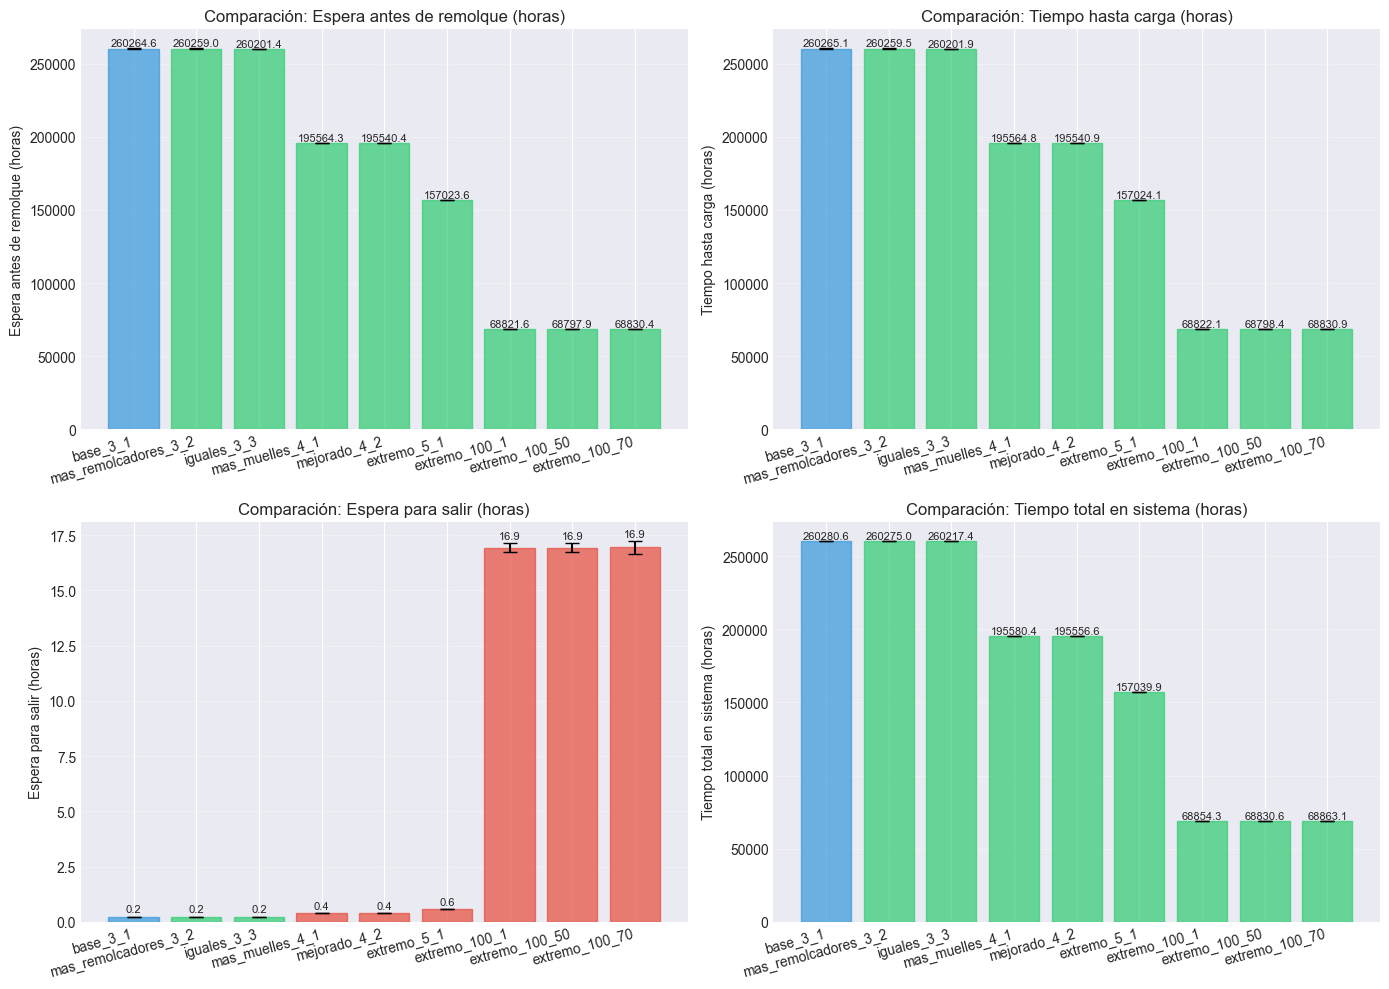

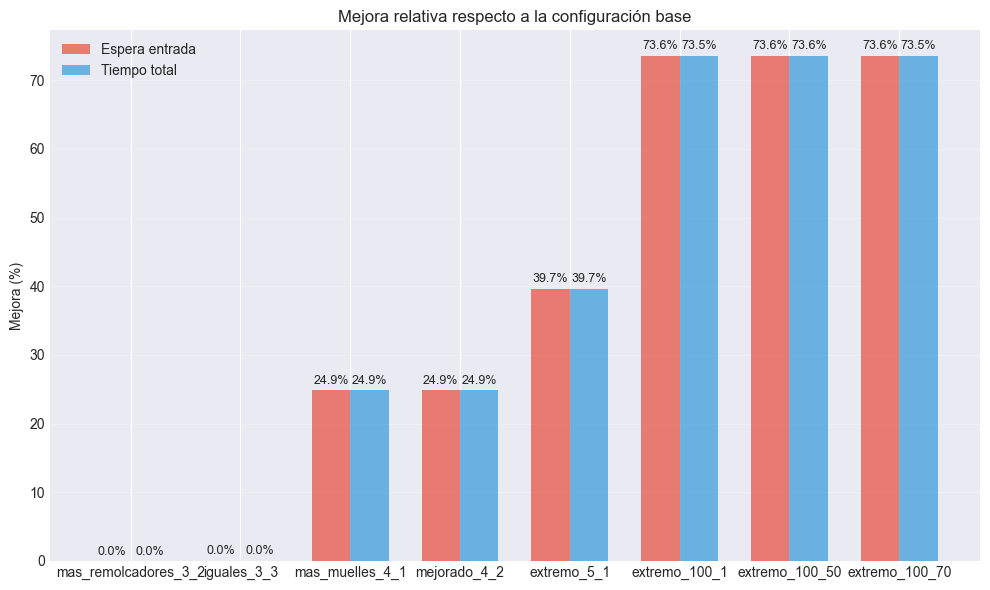


ANÁLISIS ANOVA para: inbound_wait
F-statistic: 7103374.8499
p-value: 0.000000

✅ Resultado SIGNIFICATIVO (p < 0.05)
   → Hay diferencias significativas entre las configuraciones

📊 Comparaciones por pares (Bonferroni):
--------------------------------------------------
Nivel de significancia corregido (Bonferroni): 0.001389
Número de comparaciones: 36
❌ base_3_1 vs mas_remolcadores_3_2: diferencia = 5.580, p = 0.918990
❌ base_3_1 vs iguales_3_3: diferencia = 63.186, p = 0.253354
✅ base_3_1 vs mas_muelles_4_1: diferencia = 64700.321, p = 0.000000
✅ base_3_1 vs mejorado_4_2: diferencia = 64724.203, p = 0.000000
✅ base_3_1 vs extremo_5_1: diferencia = 103241.044, p = 0.000000
✅ base_3_1 vs extremo_100_1: diferencia = 191443.039, p = 0.000000
✅ base_3_1 vs extremo_100_50: diferencia = 191466.682, p = 0.000000
✅ base_3_1 vs extremo_100_70: diferencia = 191434.179, p = 0.000000
❌ mas_remolcadores_3_2 vs iguales_3_3: diferencia = 57.606, p = 0.238889
✅ mas_remolcadores_3_2 vs mas_muelles_4_1

In [17]:
a=run_complete_sensitivity_analysis()

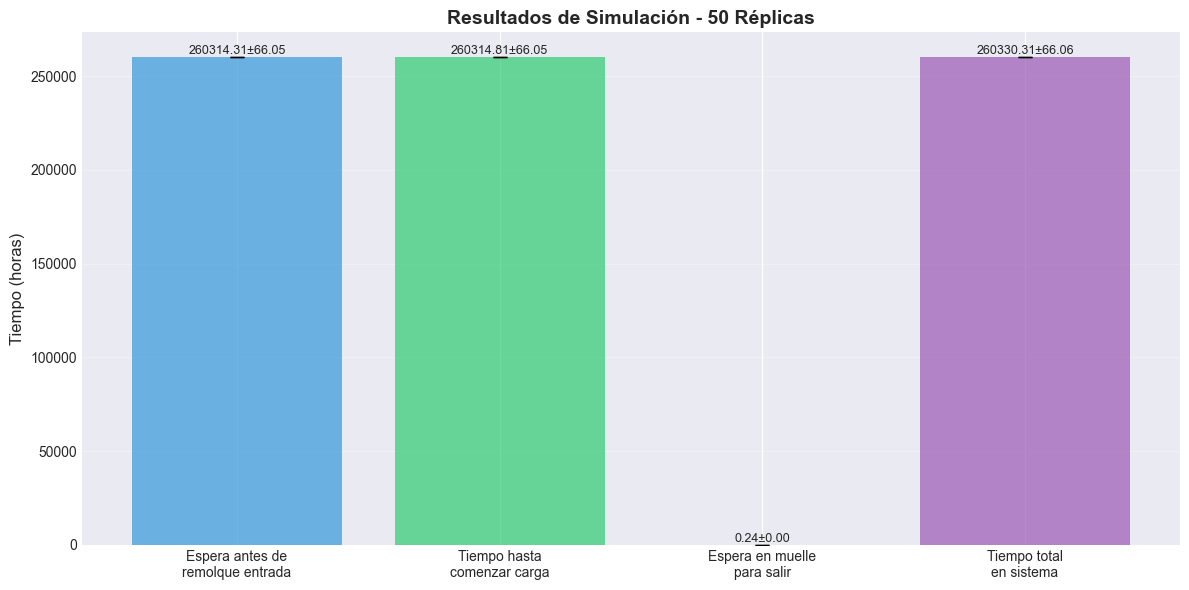

/var/folders/0z/81q974151kg7hrf0756m6s940000gn/T/ipykernel_47132/1479855580.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_to_plot, labels=labels, patch_artist=True)


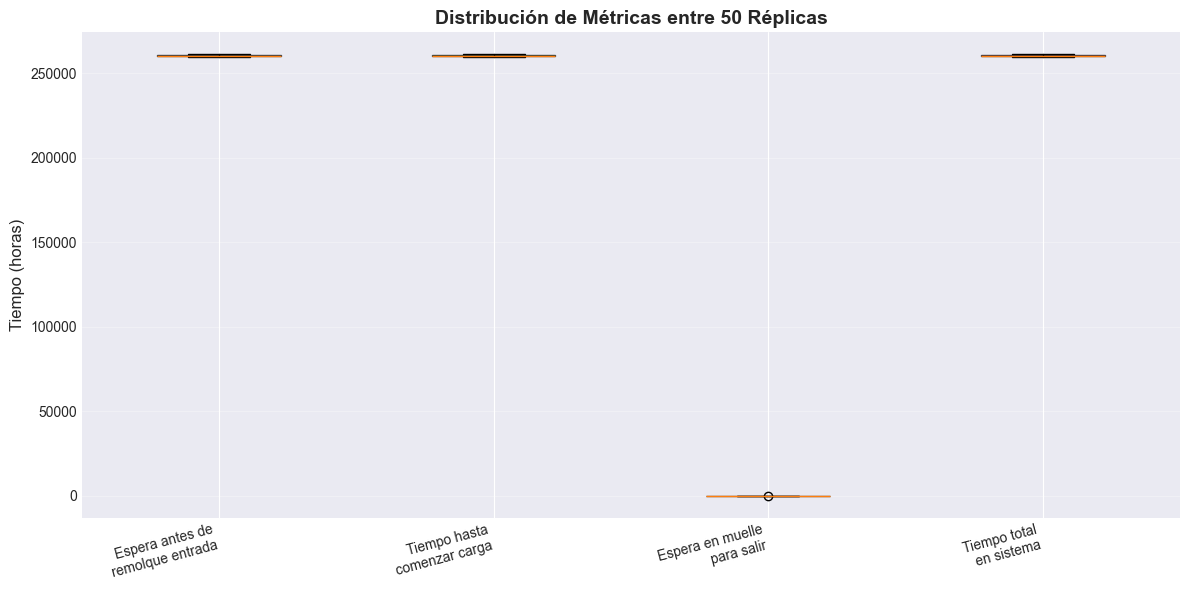

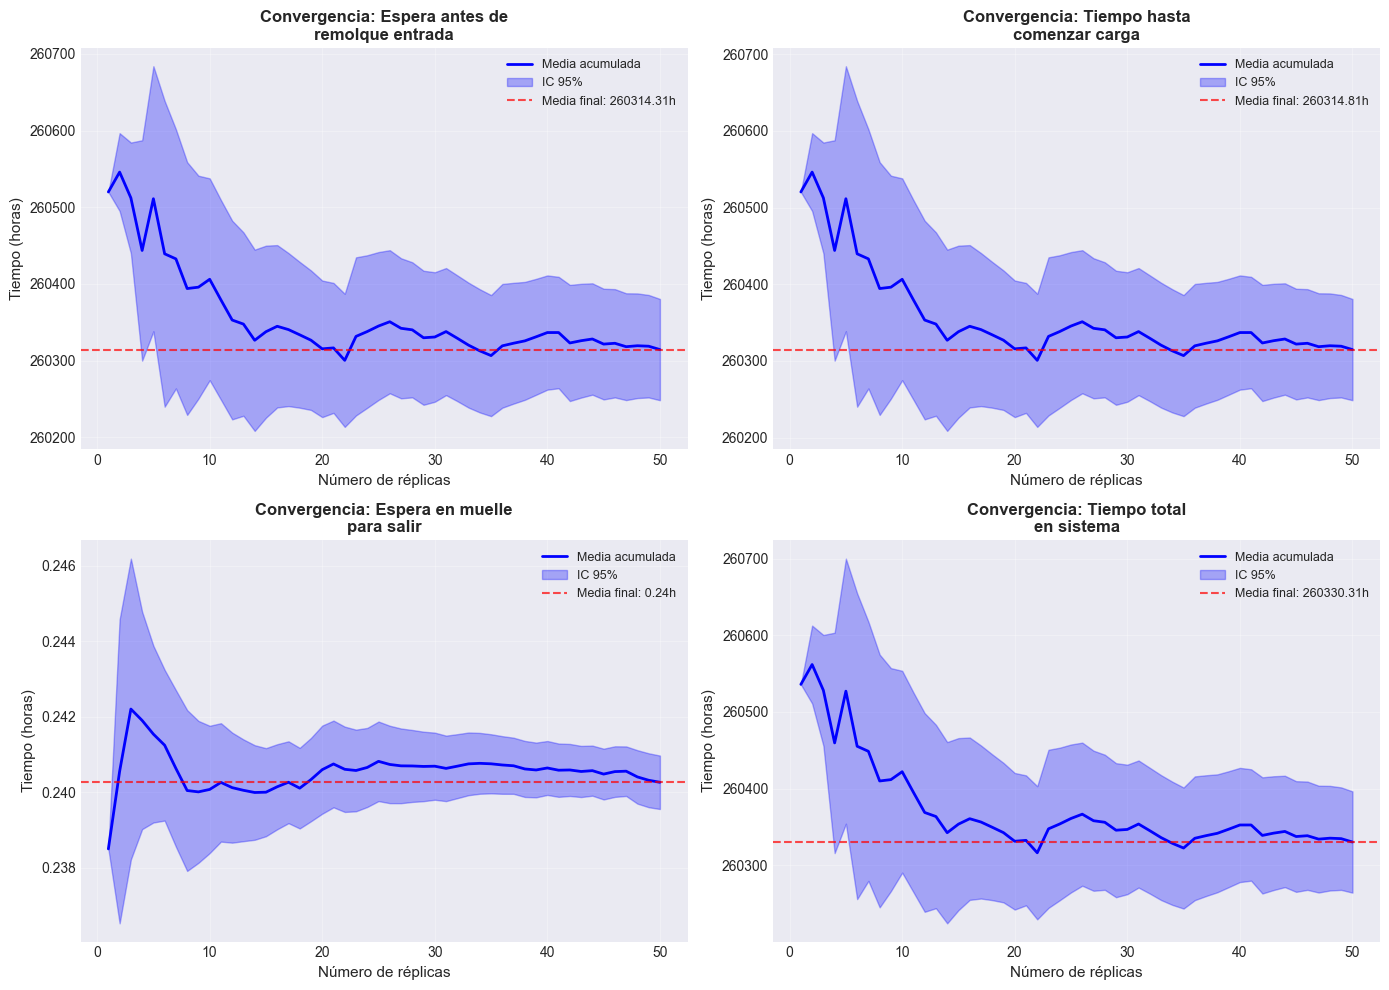

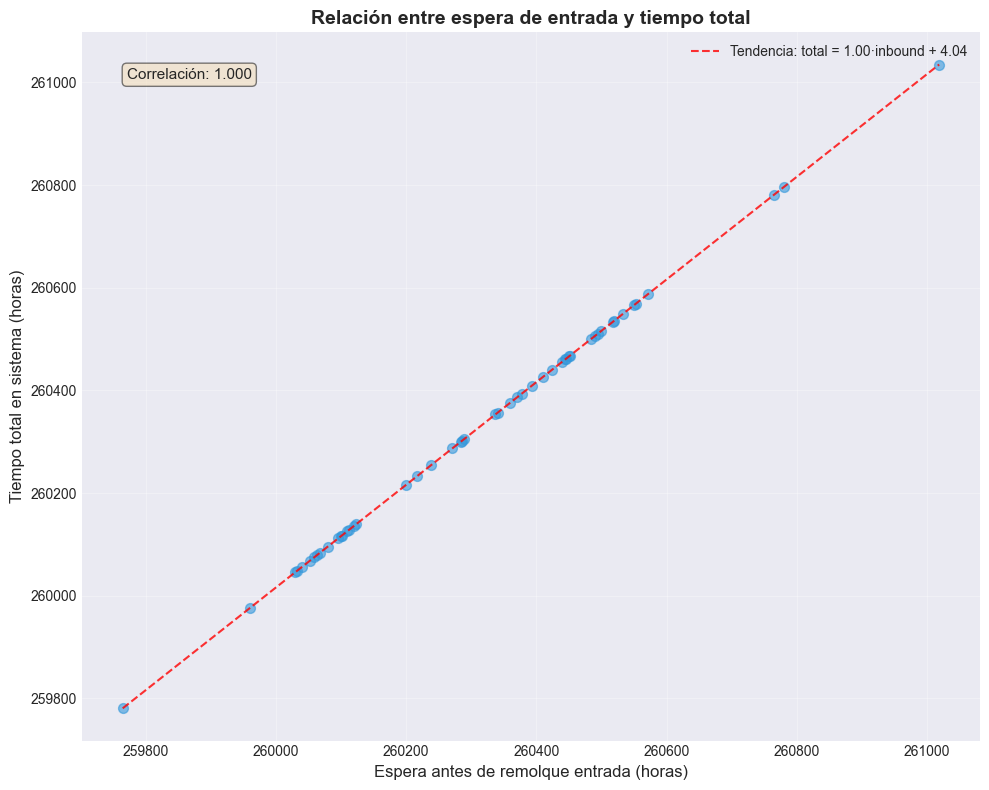

In [18]:
  
results = []
for replication in range(REPLICATIONS):
    simulation = PortSimulation(SEED + replication,3,1)
    results.append(simulation.simulate())

plot_simulation_results(results)
